# Explainable Inverse Design Analysis of Couplers

This notebook demonstrates how to use the `squadds.ml` module to analyze the `coupler-CapNInterdigitalTee-cap_matrix` dataset. 

We will:
1. Load the curated dataset.
2. Use **Explainable Boosting Machines (EBM)** to identify the key geometric parameters (features) that drive each capacitance (target).
3. Use **Symbolic Regression (PySR)** to derive analytical equations for these capacitances.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from squadds.ml.pipeline import SQuADDSAnalysisPipeline
from squadds.ml.utils import prepare_features_with_interactions

 /Users/shanto/LFL/SQuADDS_Refactor/.venv/lib/python3.11/site-packages/tqdm/auto.py: 21

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


## 1. Load Data
Load the curated dataset containing geometry parameters and simulated capacitance values.

In [2]:
# Load dataset
df = pd.read_csv("../coupler_capacitance_data.csv")
print(f"Dataset shape: {df.shape}")

Dataset shape: (430, 10)


In [3]:
def split_finger_count(fc):
    if fc == 1:
        return 1, 0  # Special case: 1 finger on bottom, 0 on top
    elif fc % 2 == 0:
        return fc // 2, fc // 2
    else:
        return (fc + 1) // 2, (fc - 1) // 2

# Apply to dataframe
df[['bottom_finger_count', 'top_finger_count']] = df['finger_count'].apply(
    lambda x: pd.Series(split_finger_count(x))
)

df[['finger_count', 'bottom_finger_count', 'top_finger_count']].drop_duplicates().sort_values('finger_count')

,finger_count,bottom_finger_count,top_finger_count
0,1.0,1.0,0.0
2,2.0,1.0,1.0
12,3.0,2.0,1.0
18,4.0,2.0,2.0
15,5.0,3.0,2.0
3,6.0,3.0,3.0
5,7.0,4.0,3.0
1,8.0,4.0,4.0
8,9.0,5.0,4.0
6,10.0,5.0,5.0


In [4]:
df

,cap_gap,cap_width,finger_count,finger_length,bottom_to_bottom,bottom_to_ground,ground_to_ground,top_to_bottom,top_to_ground,top_to_top,bottom_finger_count,top_finger_count
0,2.1,4.9,1.0,25.9,12.78614,12.09846,58.45017,0.51663,14.95437,15.65491,1.0,0.0
1,2.1,10.9,8.0,45.9,94.96956,58.07364,124.18885,36.28408,29.22434,65.85844,4.0,4.0
2,4.1,6.9,2.0,35.9,21.94864,18.77498,66.60369,2.88026,15.65588,18.77838,1.0,1.0
3,2.1,6.9,6.0,45.9,55.18578,33.69106,88.75992,21.05076,20.98596,42.46632,3.0,3.0
4,4.1,8.9,6.0,45.9,60.57606,41.62987,101.33585,18.40010,24.77954,43.49158,3.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...
425,2.1,10.9,1.0,35.9,15.86284,14.59008,64.32406,1.02606,18.87248,20.16504,1.0,0.0
426,4.1,12.9,2.0,25.9,28.43531,24.50768,74.50121,3.57699,17.41757,21.23155,1.0,1.0
427,4.1,10.9,5.0,45.9,55.36257,38.54199,102.24635,16.38109,28.66939,45.47336,3.0,2.0
428,4.1,4.9,4.0,15.9,23.20076,19.39282,65.27181,3.52960,14.36617,18.15142,2.0,2.0


## 2. Define Features and Targets
We identified the varying design parameters in the previous step.

In [5]:
features = ['cap_gap', 'cap_width', 'bottom_finger_count', 'top_finger_count', 'finger_length']
targets = ['bottom_to_bottom', 'bottom_to_ground', 'ground_to_ground', 
           'top_to_bottom', 'top_to_ground', 'top_to_top']

### 2.1 Visualize Dataset
Let's look at the distribution of our design parameters and target capacitances.

In [6]:
def plot_dataset_distributions(df, features, targets):
    # Plot features
    n_features = len(features)
    cols = min(n_features, 5)  
    plt.figure(figsize=(18, 4)) # Wider figure
    for i, col in enumerate(features):
        plt.subplot(1, n_features, i+1)
        sns.histplot(df[col], kde=True, color='skyblue')
        plt.title(f'Feature: {col}')
        plt.xlabel(col)
    plt.tight_layout()
    plt.show()
    
    # Plot targets
    plt.figure(figsize=(15, 8))
    for i, col in enumerate(targets):
        plt.subplot(2, 3, i+1)
        sns.histplot(df[col], kde=True, color='salmon')
        plt.title(f'Target: {col}')
        plt.xlabel(col)
    plt.tight_layout()
    plt.show()

## 3. Run Analysis Pipeline
We run the analysis for each target. The pipeline will:
- Train an EBM to find important features and interactions.
- Feed those features to PySR to find analytical equations.

**Note:** For demonstration speed, we limit PySR iterations (`niterations=20`). Increase this value (e.g., to 100) for more accurate and robust equations.

In [7]:
pipeline = SQuADDSAnalysisPipeline(random_state=42)

# Output dictionary to store results
results = pipeline.analyze(
    df,
    features,
    targets,
    test_size=0.1,
    # EBM params
    ebm_kwargs={'interactions': 10, 'outer_bags': 16, 'inner_bags': 0, 'learning_rate': 0.005},
    # PySR params - keep low for demo, increase for production
    symbolic_kwargs={'verbosity': 0, 'progress': False, 
        'parsimony': 0.05,
        'niterations': 200,
        'populations': 30,
        'binary_operators': ["+", "-", "*", "/"],
        'unary_operators': ["sqrt", "inv", "square"],
        'maxsize': 20,
    },
    feature_threshold=0.05  # Be stricter about which features to even consider
)

INFO:interpret.utils._native:EBM lib loading.


Analyzing target: bottom_to_bottom...
  Training EBM for feature selection...


INFO:interpret.utils._native:Finding library for Darwin, arm64, bitsize=64, debug=False
INFO:interpret.utils._native:Loading EBM library /Users/shanto/LFL/SQuADDS_Refactor/.venv/lib/python3.11/site-packages/interpret/utils/../root/bld/lib/libebm_mac_arm.dylib
INFO:interpret.utils._compressed_dataset:Creating native dataset
INFO:interpret.utils._compressed_dataset:Creating native dataset
INFO:interpret.glassbox._ebm._ebm:Estimating with FAST


  Selected features: ['finger_length', 'top_finger_count', 'cap_width', 'bottom_finger_count']
  Selected interactions: [('cap_width', 'top_finger_count')]
  Training Symbolic Regressor...


INFO:interpret.utils._compressed_dataset:Creating native dataset


...

  Selected features: ['top_finger_count', 'finger_length', 'cap_width', 'bottom_finger_count']
  Selected interactions: [('cap_width', 'bottom_finger_count'), ('bottom_finger_count', 'finger_length'), ('top_finger_count', 'finger_length')]
  Training Symbolic Regressor...


INFO:interpret.utils._compressed_dataset:Creating native dataset


  Best Equation: (finger_length + 98.469246)*0.0025340186*(cap_width_x_bottom_finger_count + 41.240837)
Analyzing target: top_to_top...
  Training EBM for feature selection...


INFO:interpret.utils._compressed_dataset:Creating native dataset
INFO:interpret.glassbox._ebm._ebm:Estimating with FAST


  Selected features: ['finger_length', 'top_finger_count', 'cap_width', 'bottom_finger_count']
  Selected interactions: [('bottom_finger_count', 'finger_length')]
  Training Symbolic Regressor...
  Best Equation: sqrt(bottom_finger_count_x_finger_length + 12.422226)*(cap_width*(0.037470322*top_finger_count + 0.09973201) + 1.8840263)


## 4. View Results
### Best Equations

In [8]:
# Print all equations without truncation
for t, r in results.items():
    print(f"{t:<20} | R2: {r['symbolic_metrics']['r2']:.4f}")
    print(f"Eq: {r['best_equation']}")
    print("-" * 80)

bottom_to_bottom     | R2: 0.9899
Eq: cap_width_x_top_finger_count - 1*(-12.463314) + finger_length*(cap_width + top_finger_count)/((74.02448/bottom_finger_count))
--------------------------------------------------------------------------------
bottom_to_ground     | R2: 0.9937
Eq: cap_width_x_bottom_finger_count*0.30788624 + cap_width_x_top_finger_count*0.731769 - 1*(-10.78353)
--------------------------------------------------------------------------------
ground_to_ground     | R2: 0.9948
Eq: finger_length/3.2829912 + (cap_width_x_bottom_finger_count + cap_width_x_top_finger_count)*0.73804355 - 1*(-45.940113)
--------------------------------------------------------------------------------
top_to_bottom        | R2: 0.9922
Eq: sqrt(top_finger_count_x_finger_length*(0.30352047*bottom_finger_count*(-0.13734297*cap_gap*cap_width + cap_width) + 1.3907417) + 124.42265) - 10.391868
--------------------------------------------------------------------------------
top_to_ground        | R2: 0

### Feature Importance (EBM)
Visualizing the contribution of each feature to the target capacitance.

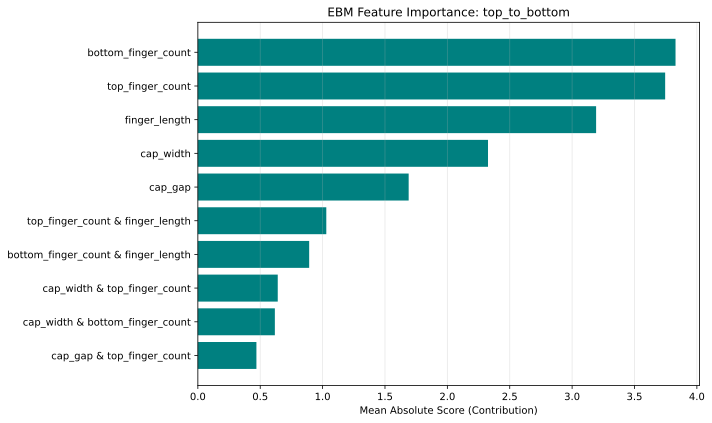

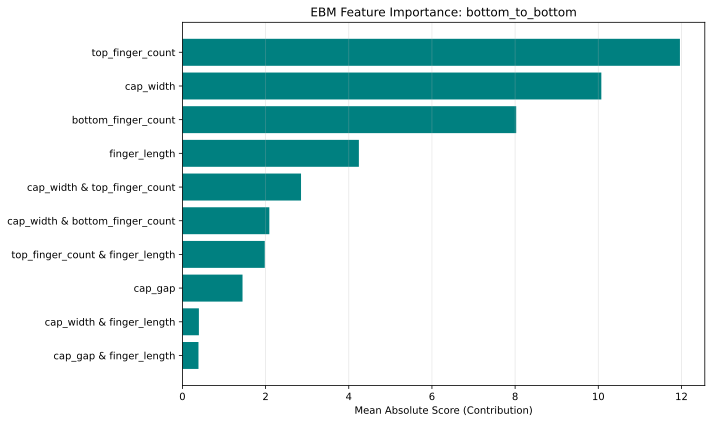

In [9]:
def plot_ebm_feature_importance(results, target_name):
    if target_name not in results:
        return
    
    res = results[target_name]
    # Access internal InterpretML model from EBMAnalyzer wrapper
    ebm = res['ebm_model'].model  
    
    # Get importances and term names
    term_importances = ebm.term_importances()
    term_names = ebm.term_names_
    
    # Sort by importance
    indices = np.argsort(term_importances)[::-1]
    top_n = min(10, len(indices))
    top_indices = indices[:top_n]
    
    plt.figure(figsize=(10, 6))
    plt.barh(range(top_n), term_importances[top_indices], align='center', color='teal')
    plt.yticks(range(top_n), [term_names[i] for i in top_indices])
    plt.gca().invert_yaxis()
    plt.xlabel('Mean Absolute Score (Contribution)')
    plt.title(f'EBM Feature Importance: {target_name}')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot for top 2 targets
plot_ebm_feature_importance(results, 'top_to_bottom')
plot_ebm_feature_importance(results, 'bottom_to_bottom')

### Pareto Front (PySR)
Visualizing the trade-off between equation complexity and accuracy (loss).

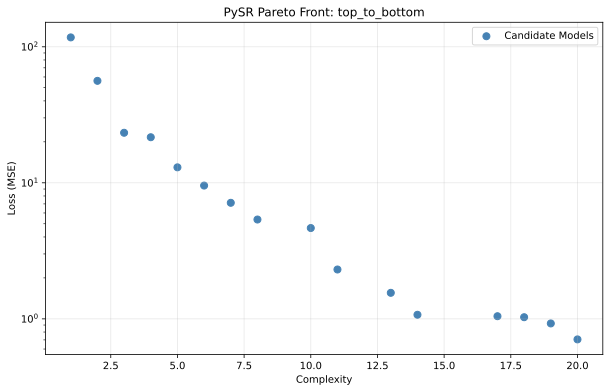

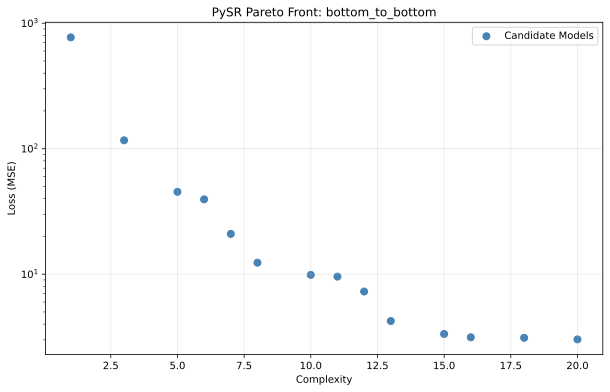

In [10]:
def plot_pareto_front(results, target_name):
    if target_name not in results:
        return
        
    res = results[target_name]
    sym_reg = res['symbolic_model']
    
    # Get equations dataframe from SymbolicRegressor wrapper
    equations = sym_reg.get_equations()
    
    plt.figure(figsize=(10, 6))
    plt.scatter(equations['complexity'], equations['loss'], c='steelblue', s=50, label='Candidate Models')
    
    # Highlight best model selected by PySR
    best_eqn_str = res['best_equation']
    # Handle potential differences in string formatting if necessary, but exact match usually works
    # Alternatively, PySR's equations dataframe often has a 'selection' column implied by model choice logic
    # Here we just match the string equation
    best_row = equations[equations['equation'] == best_eqn_str]
    
    if not best_row.empty:
        plt.scatter(best_row['complexity'], best_row['loss'], c='red', s=100, marker='*', label='Best Model')
    
    plt.xlabel('Complexity')
    plt.ylabel('Loss (MSE)')
    plt.yscale('log')
    plt.title(f'PySR Pareto Front: {target_name}')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

# Plot for top 2 targets
plot_pareto_front(results, 'top_to_bottom')
plot_pareto_front(results, 'bottom_to_bottom')

### Parity Plots
Visualizing the agreement between the Symbolic Regression model predictions and the true data.

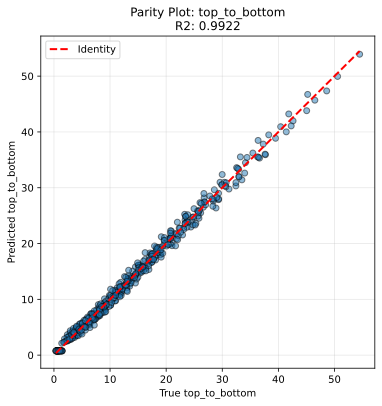

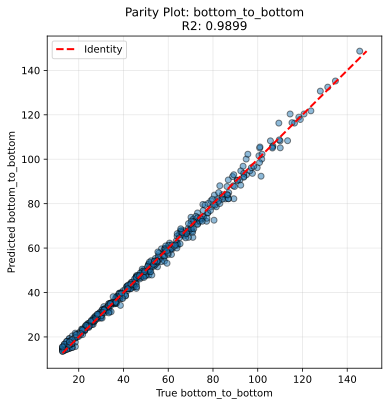

In [11]:
def plot_parity(results, df, target_name):
    if target_name not in results:
        return
    
    res = results[target_name]
    sym_model = res['symbolic_model']
    
    # Get features
    base_feats = res['selected_features']
    inte_pairs = res['interaction_pairs']
    
    # Prepare X
    X_all = df[features]
    X_sym = prepare_features_with_interactions(X_all, base_feats, inte_pairs)
    
    # Predict
    y_pred = sym_model.predict(X_sym)
    y_true = df[target_name]
    
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.5, edgecolor='k')
    
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Identity')
    
    plt.xlabel(f"True {target_name}")
    plt.ylabel(f"Predicted {target_name}")
    plt.title(f"Parity Plot: {target_name}\nR2: {res['symbolic_metrics']['r2']:.4f}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Plot for top 2 targets
plot_parity(results, df, 'top_to_bottom')
plot_parity(results, df, 'bottom_to_bottom')

## Hyperparameter Study: Finding the Best Physics

We will now systematically test different hyperparameter configurations to find the most physically valid equations. 
Our goal is to balance **accuracy ($R^2$)** with **parsimony (simple, interpretable equations)**, avoiding overfitting to noise.

In [12]:
def run_experiment(name, ebm_kwargs, symbolic_kwargs):
    print(f"\n{'='*80}\nRUNNING EXPERIMENT: {name}\n{'='*80}")
    pipeline = SQuADDSAnalysisPipeline(random_state=42)
    try:
        results = pipeline.analyze(
            df,
            features,
            targets,
            test_size=0.1,
            ebm_kwargs=ebm_kwargs,
            symbolic_kwargs=symbolic_kwargs,
            feature_threshold=0.05
        )
        print(f"Experiment '{name}' Completed.")
        return results
    except Exception as e:
        print(f"Experiment '{name}' Failed: {e}")
        return None

### Experiment 1: v5 Baseline (Speed-Optimized)

In [13]:
# Baseline settings from Tutorial v5
results_v5 = run_experiment(
    "v5 Baseline",
    ebm_kwargs={'interactions': 10, 'outer_bags': 8, 'learning_rate': 0.01},
    symbolic_kwargs={'verbosity': 0, 'progress': False, 
        'niterations': 50,
        'populations': 15,
        'binary_operators': ["+", "-", "*", "/"],
        'unary_operators': ["sqrt", "inv", "square"],
        'maxsize': 20,
        'parsimony': 0.0032,
    }
)

INFO:interpret.utils._compressed_dataset:Creating native dataset



RUNNING EXPERIMENT: v5 Baseline
Analyzing target: bottom_to_bottom...
  Training EBM for feature selection...


INFO:interpret.utils._compressed_dataset:Creating native dataset
INFO:interpret.glassbox._ebm._ebm:Estimating with FAST


  Selected features: ['finger_length', 'top_finger_count', 'cap_width', 'bottom_finger_count']
  Selected interactions: [('cap_width', 'top_finger_count')]
  Training Symbolic Regressor...


INFO:interpret.utils._compressed_dataset:Creating native dataset


...

  Selected features: ['finger_length', 'top_finger_count', 'cap_width', 'bottom_finger_count']
  Selected interactions: [('cap_width', 'bottom_finger_count'), ('bottom_finger_count', 'finger_length'), ('top_finger_count', 'finger_length')]
  Training Symbolic Regressor...


INFO:interpret.utils._compressed_dataset:Creating native dataset


  Best Equation: 8.048713 - (cap_width_x_bottom_finger_count*(-0.3281586) - 0.17659463*finger_length)
Analyzing target: top_to_top...
  Training EBM for feature selection...


INFO:interpret.utils._compressed_dataset:Creating native dataset
INFO:interpret.glassbox._ebm._ebm:Estimating with FAST


  Selected features: ['finger_length', 'top_finger_count', 'cap_width', 'bottom_finger_count']
  Selected interactions: [('bottom_finger_count', 'finger_length')]
  Training Symbolic Regressor...
  Best Equation: sqrt(sqrt(bottom_finger_count)*bottom_finger_count_x_finger_length*cap_width + 74.18926)
Experiment 'v5 Baseline' Completed.


### Experiment 2: Recommended High Accuracy (Deep Search)

In [14]:
# Recommended settings for physical discovery
results_rec = run_experiment(
    "Recommended High Accuracy",
    ebm_kwargs={'interactions': 20, 'outer_bags': 16, 'learning_rate': 0.005},
    symbolic_kwargs={'verbosity': 0, 'progress': False, 
        'niterations': 200,      # significantly increased
        'populations': 30,
        'binary_operators': ["+", "-", "*", "/"], # Added 'pow'
        'unary_operators': ["sqrt", "inv", "square"],
        'maxsize': 25,
        'parsimony': 0.004,      # slightly higher to heavily penalize complexity
        'complexity_of_constants': 2 # Penalize magic numbers
    }
)

INFO:interpret.utils._compressed_dataset:Creating native dataset



RUNNING EXPERIMENT: Recommended High Accuracy
Analyzing target: bottom_to_bottom...
  Training EBM for feature selection...


INFO:interpret.utils._compressed_dataset:Creating native dataset
INFO:interpret.glassbox._ebm._ebm:Estimating with FAST


  Selected features: ['finger_length', 'top_finger_count', 'cap_width', 'bottom_finger_count']
  Selected interactions: [('cap_width', 'top_finger_count')]
  Training Symbolic Regressor...


INFO:interpret.utils._compressed_dataset:Creating native dataset


...

  Selected features: ['top_finger_count', 'finger_length', 'cap_width', 'bottom_finger_count']
  Selected interactions: [('cap_width', 'bottom_finger_count'), ('bottom_finger_count', 'finger_length'), ('top_finger_count', 'finger_length')]
  Training Symbolic Regressor...


INFO:interpret.utils._compressed_dataset:Creating native dataset


  Best Equation: 0.14047456*finger_length**(1/4)*(cap_width_x_bottom_finger_count + 41.390137)
Analyzing target: top_to_top...
  Training EBM for feature selection...


INFO:interpret.utils._compressed_dataset:Creating native dataset
INFO:interpret.glassbox._ebm._ebm:Estimating with FAST


  Selected features: ['finger_length', 'top_finger_count', 'cap_width', 'bottom_finger_count']
  Selected interactions: [('bottom_finger_count', 'finger_length')]
  Training Symbolic Regressor...
  Best Equation: (bottom_finger_count*(cap_width**2*(-bottom_finger_count_x_finger_length + cap_width)**2 + cap_width**2*(cap_width*top_finger_count + cap_width)**2) + 62900.543)**(1/4)
Experiment 'Recommended High Accuracy' Completed.


### Experiment 3: Parsimonious Physics (Forced Simplicity)

In [15]:
# Forcing simple, short equations
results_pars = run_experiment(
    "Parsimonious Physics",
    ebm_kwargs={'interactions': 5, 'outer_bags': 8},
    symbolic_kwargs={'verbosity': 0, 'progress': False, 
        'niterations': 200,
        'parsimony': 0.05,       # VERY high penalty for length
        'binary_operators': ["+", "-", "*", "/"],
        'unary_operators': ["sqrt", "inv", "square"],
        'maxsize': 12            # Hard limit on length
    }
)

INFO:interpret.utils._compressed_dataset:Creating native dataset



RUNNING EXPERIMENT: Parsimonious Physics
Analyzing target: bottom_to_bottom...
  Training EBM for feature selection...


INFO:interpret.utils._compressed_dataset:Creating native dataset
INFO:interpret.glassbox._ebm._ebm:Estimating with FAST


  Selected features: ['finger_length', 'top_finger_count', 'cap_width', 'bottom_finger_count']
  Selected interactions: [('cap_width', 'bottom_finger_count'), ('cap_width', 'top_finger_count')]
  Training Symbolic Regressor...


INFO:interpret.utils._compressed_dataset:Creating native dataset


...

  Selected features: ['finger_length', 'top_finger_count', 'cap_width', 'bottom_finger_count']
  Selected interactions: [('cap_width', 'bottom_finger_count'), ('bottom_finger_count', 'finger_length')]
  Training Symbolic Regressor...


INFO:interpret.utils._compressed_dataset:Creating native dataset


  Best Equation: 0.3378133*cap_width_x_bottom_finger_count + 2.40635084113994*sqrt(finger_length)
Analyzing target: top_to_top...
  Training EBM for feature selection...


INFO:interpret.utils._compressed_dataset:Creating native dataset
INFO:interpret.glassbox._ebm._ebm:Estimating with FAST


  Selected features: ['finger_length', 'top_finger_count', 'cap_width', 'bottom_finger_count']
  Selected interactions: [('bottom_finger_count', 'finger_length')]
  Training Symbolic Regressor...
  Best Equation: sqrt(sqrt(bottom_finger_count)*bottom_finger_count_x_finger_length*cap_width + 74.20584)
Experiment 'Parsimonious Physics' Completed.


### Experiment 4: Complex Interactions (Many Cross-Terms)

In [16]:
# Allowing many interaction terms
results_complex = run_experiment(
    "Complex Interactions",
    ebm_kwargs={'interactions': 50, 'outer_bags': 8, 'max_bins': 512},
    symbolic_kwargs={'verbosity': 0, 'progress': False, 
        'niterations': 100,
        'maxsize': 30,
        'parsimony': 0.001       # Low penalty, allow long equations
    }
)

INFO:interpret.utils._compressed_dataset:Creating native dataset



RUNNING EXPERIMENT: Complex Interactions
Analyzing target: bottom_to_bottom...
  Training EBM for feature selection...


INFO:interpret.utils._compressed_dataset:Creating native dataset
INFO:interpret.glassbox._ebm._ebm:Estimating with FAST


  Selected features: ['finger_length', 'top_finger_count', 'cap_width', 'bottom_finger_count']
  Selected interactions: [('cap_width', 'top_finger_count')]
  Training Symbolic Regressor...


INFO:interpret.utils._compressed_dataset:Creating native dataset


...

  Selected features: ['finger_length', 'top_finger_count', 'cap_width', 'bottom_finger_count']
  Selected interactions: [('cap_width', 'bottom_finger_count'), ('bottom_finger_count', 'finger_length'), ('top_finger_count', 'finger_length')]
  Training Symbolic Regressor...


INFO:interpret.utils._compressed_dataset:Creating native dataset


  Best Equation: (cap_width_x_bottom_finger_count + cap_width_x_bottom_finger_count + finger_length + 50.403152)*0.16526783
Analyzing target: top_to_top...
  Training EBM for feature selection...


INFO:interpret.utils._compressed_dataset:Creating native dataset
INFO:interpret.glassbox._ebm._ebm:Estimating with FAST


  Selected features: ['finger_length', 'top_finger_count', 'cap_width', 'bottom_finger_count']
  Selected interactions: [('bottom_finger_count', 'finger_length')]
  Training Symbolic Regressor...
  Best Equation: sqrt(cap_width*(0.2987263*bottom_finger_count_x_finger_length + 3.9897814)*(top_finger_count + 2.5725405))
Experiment 'Complex Interactions' Completed.


### Experiment 5: Pure Superposition (No Interactions)

In [17]:
# Testing if simple addition of effects explains the data
results_no_int = run_experiment(
    "No Interactions",
    ebm_kwargs={'interactions': 0}, # Disable interactions
    symbolic_kwargs={'verbosity': 0, 'progress': False, 
        'niterations': 200,
        'binary_operators': ["+", "-", "*", "/"],
    }
)

INFO:interpret.utils._compressed_dataset:Creating native dataset



RUNNING EXPERIMENT: No Interactions
Analyzing target: bottom_to_bottom...
  Training EBM for feature selection...
  Selected features: ['finger_length', 'top_finger_count', 'cap_width', 'bottom_finger_count']
  Selected interactions: []
  Training Symbolic Regressor...


INFO:interpret.utils._compressed_dataset:Creating native dataset


  Best Equation: cap_width*top_finger_count - ((0.151100946668637*cap_width**2 + finger_length)*(-0.14734617)*bottom_finger_count - 7.966337)
Analyzing target: bottom_to_ground...
  Training EBM for feature selection...
  Selected features: ['top_finger_count', 'cap_width', 'bottom_finger_count']
  Selected interactions: []
  Training Symbolic Regressor...


INFO:interpret.utils._compressed_dataset:Creating native dataset


...

  Best Equation: cap_width*(bottom_finger_count + top_finger_count)*0.7380573 + finger_length*0.30461648 + 45.938595
Analyzing target: top_to_bottom...
  Training EBM for feature selection...
  Selected features: ['top_finger_count', 'cap_width', 'bottom_finger_count', 'finger_length', 'cap_gap']
  Selected interactions: []
  Training Symbolic Regressor...


INFO:interpret.utils._compressed_dataset:Creating native dataset


  Best Equation: (0.187602460256184*bottom_finger_count + 0.187602460256184*top_finger_count - 0.147302337592316)*(cap_width + 0.651393675130485*finger_length*sqrt(1/cap_gap) - 5.167898)
Analyzing target: top_to_ground...
  Training EBM for feature selection...
  Selected features: ['top_finger_count', 'cap_width', 'bottom_finger_count', 'finger_length', 'cap_gap']
  Selected interactions: []
  Training Symbolic Regressor...


INFO:interpret.utils._compressed_dataset:Creating native dataset


  Best Equation: 0.33375746*bottom_finger_count*cap_width + cap_gap + 1.90283772298113*sqrt(finger_length)
Analyzing target: top_to_top...
  Training EBM for feature selection...
  Selected features: ['top_finger_count', 'cap_width', 'bottom_finger_count', 'finger_length', 'cap_gap']
  Selected interactions: []
  Training Symbolic Regressor...
  Best Equation: 0.66540071961757*sqrt(bottom_finger_count**2*(-sqrt(cap_gap) + cap_width)*(-cap_gap + finger_length)) + 9.763576
Experiment 'No Interactions' Completed.


### Experiment 6: Maximum Effort (Deepest Search)

In [18]:
# Massive search space
results_max = run_experiment(
    "Maximum Effort",
    ebm_kwargs={'interactions': 20, 'outer_bags': 24, 'learning_rate': 0.001},
    symbolic_kwargs={'verbosity': 0, 'progress': False, 
        'niterations': 500,
        'populations': 50,
        'binary_operators': ["+", "-", "*", "/", "pow"],
        'population_size': 50,
        'maxsize': 30,
    }
)

INFO:interpret.utils._compressed_dataset:Creating native dataset



RUNNING EXPERIMENT: Maximum Effort
Analyzing target: bottom_to_bottom...
  Training EBM for feature selection...


INFO:interpret.utils._compressed_dataset:Creating native dataset
INFO:interpret.glassbox._ebm._ebm:Estimating with FAST


  Selected features: ['finger_length', 'top_finger_count', 'cap_width', 'bottom_finger_count']
  Selected interactions: [('cap_width', 'top_finger_count')]
  Training Symbolic Regressor...


 /Users/shanto/LFL/SQuADDS_Refactor/.venv/lib/python3.11/site-packages/pysr/sr.py: 96INFO:interpret.utils._compressed_dataset:Creating native dataset


...

  Best Equation: bottom_finger_count_x_finger_length*0.37780455/(bottom_finger_count + top_finger_count + 0.9633816) + cap_width_x_bottom_finger_count/3.1410546 + 8.433835
Analyzing target: top_to_top...
  Training EBM for feature selection...


INFO:interpret.utils._compressed_dataset:Creating native dataset
INFO:interpret.glassbox._ebm._ebm:Estimating with FAST


  Selected features: ['finger_length', 'top_finger_count', 'cap_width', 'bottom_finger_count']
  Selected interactions: [('cap_width', 'bottom_finger_count'), ('bottom_finger_count', 'finger_length')]
  Training Symbolic Regressor...


 /Users/shanto/LFL/SQuADDS_Refactor/.venv/lib/python3.11/site-packages/pysr/sr.py: 96

  Best Equation: 0.05821943*bottom_finger_count_x_finger_length*sqrt(cap_width) + 0.20734297*cap_width*top_finger_count + 0.20734297*cap_width_x_bottom_finger_count + 10.6764577664147
Experiment 'Maximum Effort' Completed.


Experiment 7: Maximum Effort (No Power)

In [22]:
# Massive search space
results_max_no_pow = run_experiment(
    "Maximum Effort",
    ebm_kwargs={'interactions': 20, 'outer_bags': 24, 'learning_rate': 0.001},
    symbolic_kwargs={'verbosity': 0, 'progress': False, 
        'niterations': 500,
        'populations': 50,
        'binary_operators': ["+", "-", "*", "/"],
        'population_size': 50,
        'maxsize': 30,
    }
)

INFO:interpret.utils._compressed_dataset:Creating native dataset



RUNNING EXPERIMENT: Maximum Effort
Analyzing target: bottom_to_bottom...
  Training EBM for feature selection...


INFO:interpret.utils._compressed_dataset:Creating native dataset
INFO:interpret.glassbox._ebm._ebm:Estimating with FAST


  Selected features: ['finger_length', 'top_finger_count', 'cap_width', 'bottom_finger_count']
  Selected interactions: [('cap_width', 'top_finger_count')]
  Training Symbolic Regressor...


INFO:interpret.utils._compressed_dataset:Creating native dataset


...

  Selected features: ['top_finger_count', 'finger_length', 'cap_width', 'bottom_finger_count']
  Selected interactions: [('cap_width', 'bottom_finger_count'), ('bottom_finger_count', 'finger_length'), ('top_finger_count', 'finger_length')]
  Training Symbolic Regressor...


INFO:interpret.utils._compressed_dataset:Creating native dataset


  Best Equation: cap_width_x_bottom_finger_count*0.32880688 + finger_length*(0.15233211 - (-0.00083393045)*(bottom_finger_count_x_finger_length - top_finger_count_x_finger_length)) - 1*(-8.351994)
Analyzing target: top_to_top...
  Training EBM for feature selection...


INFO:interpret.utils._compressed_dataset:Creating native dataset
INFO:interpret.glassbox._ebm._ebm:Estimating with FAST


  Selected features: ['finger_length', 'top_finger_count', 'cap_width', 'bottom_finger_count']
  Selected interactions: [('cap_width', 'bottom_finger_count'), ('bottom_finger_count', 'finger_length')]
  Training Symbolic Regressor...
  Best Equation: 10.834993 - (-0.00700606)*(cap_width + 16.745928)*(bottom_finger_count_x_finger_length + cap_width*top_finger_count + cap_width_x_bottom_finger_count)
Experiment 'Maximum Effort' Completed.


# Model Comparison and Results

We will now compile the results from all experiments to identify the best performing and most physically interpretable models.

In [23]:
import pandas as pd

# Dictionary of all experiment results
experiments = {
    "Initial Run": results,
    "v5 Baseline": results_v5,
    "High Accuracy": results_rec,
    "Parsimonious": results_pars,
    "Complex Int.": results_complex,
    "No Interactions": results_no_int,
    "Max Effort": results_max,
    "Max Effort (No Power)": results_max_no_pow
}

# Filter out any failed experiments (None)
experiments = {k: v for k, v in experiments.items() if v is not None}

# 1. R2 Score Comparison Table
r2_data = {}
for exp_name, res in experiments.items():
    r2_data[exp_name] = {target: res[target]['symbolic_metrics']['r2'] for target in targets}

r2_df = pd.DataFrame(r2_data).T
print("Symbolic Regression R2 Scores (Higher is Better):")
display(r2_df.style.highlight_max(axis=0, color='lightgreen'))


Symbolic Regression R2 Scores (Higher is Better):


,bottom_to_bottom,bottom_to_ground,ground_to_ground,top_to_bottom,top_to_ground,top_to_top
Initial Run,0.989884,0.993665,0.994822,0.992214,0.962608,0.986751
v5 Baseline,0.985146,0.993962,0.994907,0.989678,0.963123,0.969332
High Accuracy,0.991229,0.991240,0.994534,0.992133,0.958750,0.984878
Parsimonious,0.984144,0.993666,0.994449,0.986208,0.960891,0.969331
Complex Int.,0.990674,0.993665,0.994820,0.995716,0.961148,0.982677
No Interactions,0.991960,0.993665,0.994822,0.994153,0.981839,0.983137
Max Effort,0.993004,0.993665,0.994974,0.999707,0.970575,0.990355
Max Effort (No Power),0.996364,0.993665,0.994534,0.998049,0.976760,0.991675


In [24]:
# 2. Best Equations Comparison
pd.set_option('display.max_colwidth', None)

for target in targets:
    print(f"\n{'='*80}\nTarget: {target}\n{'='*80}")
    eq_data = []
    for exp_name, res in experiments.items():
        if target in res:
            eq_data.append({
                "Experiment": exp_name,
                "R2": res[target]['symbolic_metrics']['r2'],
                "Best Equation": res[target]['best_equation']
            })
    
    eq_df = pd.DataFrame(eq_data).sort_values("R2", ascending=False)
    display(eq_df)


Target: bottom_to_bottom


,Experiment,R2,Best Equation
7,Max Effort (No Power),0.996364,bottom_finger_count*(0.0199284703428291*sqrt(cap_width) + 0.112445726305657*top_finger_count/bottom_finger_count)*(6.421941*cap_width + finger_length) + 8.916283
6,Max Effort,0.993004,0.051564336*bottom_finger_count*sqrt(cap_width)*(cap_width + finger_length) + cap_width_x_top_finger_count + 9.154341
5,No Interactions,0.991960,cap_width*top_finger_count - ((0.151100946668637*cap_width**2 + finger_length)*(-0.14734617)*bottom_finger_count - 7.966337)
2,High Accuracy,0.991229,0.525073879207489*bottom_finger_count*(sqrt(cap_width*finger_length) - 4.009889) + cap_width_x_top_finger_count + 8.571422
4,Complex Int.,0.990674,cap_width_x_top_finger_count + sqrt(bottom_finger_count*finger_length*(cap_width + sqrt(cap_width_x_top_finger_count)) + 424.3783) - 12.292599
0,Initial Run,0.989884,cap_width_x_top_finger_count - 1*(-12.463314) + finger_length*(cap_width + top_finger_count)/((74.02448/bottom_finger_count))
1,v5 Baseline,0.985146,0.1998988*sqrt(finger_length + 25.344341)*(bottom_finger_count + cap_width_x_top_finger_count + 8.097828)
3,Parsimonious,0.984144,cap_width_x_top_finger_count + sqrt(cap_width_x_bottom_finger_count*(finger_length + top_finger_count))



Target: bottom_to_ground


,Experiment,R2,Best Equation
1,v5 Baseline,0.993962,sqrt((cap_width_x_bottom_finger_count + 15.87664)*(cap_width_x_top_finger_count + 6.728746))
3,Parsimonious,0.993666,(14.727374 - (cap_width_x_bottom_finger_count*(-0.41976845) - cap_width_x_top_finger_count))*0.73224163
5,No Interactions,0.993665,(bottom_finger_count*0.42072105 + top_finger_count)*0.73177147*cap_width - 1*(-10.783831)
0,Initial Run,0.993665,cap_width_x_bottom_finger_count*0.30788624 + cap_width_x_top_finger_count*0.731769 - 1*(-10.78353)
4,Complex Int.,0.993665,cap_width_x_bottom_finger_count*0.30788633 + cap_width_x_top_finger_count*0.7317691 + 10.7835245
6,Max Effort,0.993665,cap_width_x_bottom_finger_count*0.30788577 + cap_width_x_top_finger_count*0.73176944 + 10.783535
7,Max Effort (No Power),0.993665,cap_width_x_bottom_finger_count*0.30788544 + cap_width_x_top_finger_count*0.73176974 + 10.783539
2,High Accuracy,0.991240,cap_width_x_top_finger_count + sqrt(cap_width_x_bottom_finger_count - cap_width_x_top_finger_count) + 11.647398



Target: ground_to_ground


...

,Experiment,R2,Best Equation
6,Max Effort,0.999707,(0.13140056*cap_width + (sqrt(cap_width + 5.5883737)*(0.029413503*finger_length + 1.0841706) - 3.1814864)*(bottom_finger_count + top_finger_count - 1.0508265))/cap_gap**0.37860867
7,Max Effort (No Power),0.998049,-bottom_finger_count - top_finger_count + 0.15182534*(cap_width + 13.296503)*(bottom_finger_count + top_finger_count_x_finger_length/(12.453895*sqrt(cap_gap) + sqrt(top_finger_count_x_finger_length)/bottom_finger_count) - 0.47720346)
4,Complex Int.,0.995716,(0.10588529*bottom_finger_count + 0.0075829076*top_finger_count_x_finger_length)*(bottom_finger_count - cap_gap*sqrt(top_finger_count) + cap_width + 10.102876) - 1.7206211
5,No Interactions,0.994153,(0.187602460256184*bottom_finger_count + 0.187602460256184*top_finger_count - 0.147302337592316)*(cap_width + 0.651393675130485*finger_length*sqrt(1/cap_gap) - 5.167898)
0,Initial Run,0.992214,sqrt(top_finger_count_x_finger_length*(0.30352047*bottom_finger_count*(-0.13734297*cap_gap*cap_width + cap_width) + 1.3907417) + 124.42265) - 10.391868
2,High Accuracy,0.992133,-top_finger_count_x_finger_length**(1/4) + sqrt(bottom_finger_count*cap_width*(-top_finger_count + top_finger_count_x_finger_length/(cap_gap + 2.6020534)))
1,v5 Baseline,0.989678,-top_finger_count + sqrt(bottom_finger_count*cap_width*top_finger_count_x_finger_length/(cap_gap + 2.5635097) + 7.7268877) - 2.5407348
3,Parsimonious,0.986208,bottom_finger_count + (bottom_finger_count**2 + top_finger_count_x_finger_length)/(cap_gap - (-1)*42.736286/cap_width)



Target: top_to_ground


,Experiment,R2,Best Equation
5,No Interactions,0.981839,0.33375746*bottom_finger_count*cap_width + cap_gap + 1.90283772298113*sqrt(finger_length)
7,Max Effort (No Power),0.976760,cap_width_x_bottom_finger_count*0.32880688 + finger_length*(0.15233211 - (-0.00083393045)*(bottom_finger_count_x_finger_length - top_finger_count_x_finger_length)) - 1*(-8.351994)
6,Max Effort,0.970575,bottom_finger_count_x_finger_length*0.37780455/(bottom_finger_count + top_finger_count + 0.9633816) + cap_width_x_bottom_finger_count/3.1410546 + 8.433835
1,v5 Baseline,0.963123,8.048713 - (cap_width_x_bottom_finger_count*(-0.3281586) - 0.17659463*finger_length)
0,Initial Run,0.962608,(finger_length + 98.469246)*0.0025340186*(cap_width_x_bottom_finger_count + 41.240837)
4,Complex Int.,0.961148,(cap_width_x_bottom_finger_count + cap_width_x_bottom_finger_count + finger_length + 50.403152)*0.16526783
3,Parsimonious,0.960891,0.3378133*cap_width_x_bottom_finger_count + 2.40635084113994*sqrt(finger_length)
2,High Accuracy,0.958750,0.14047456*finger_length**(1/4)*(cap_width_x_bottom_finger_count + 41.390137)



Target: top_to_top


,Experiment,R2,Best Equation
7,Max Effort (No Power),0.991675,10.834993 - (-0.00700606)*(cap_width + 16.745928)*(bottom_finger_count_x_finger_length + cap_width*top_finger_count + cap_width_x_bottom_finger_count)
6,Max Effort,0.990355,0.05821943*bottom_finger_count_x_finger_length*sqrt(cap_width) + 0.20734297*cap_width*top_finger_count + 0.20734297*cap_width_x_bottom_finger_count + 10.6764577664147
0,Initial Run,0.986751,sqrt(bottom_finger_count_x_finger_length + 12.422226)*(cap_width*(0.037470322*top_finger_count + 0.09973201) + 1.8840263)
2,High Accuracy,0.984878,(bottom_finger_count*(cap_width**2*(-bottom_finger_count_x_finger_length + cap_width)**2 + cap_width**2*(cap_width*top_finger_count + cap_width)**2) + 62900.543)**(1/4)
5,No Interactions,0.983137,0.66540071961757*sqrt(bottom_finger_count**2*(-sqrt(cap_gap) + cap_width)*(-cap_gap + finger_length)) + 9.763576
4,Complex Int.,0.982677,sqrt(cap_width*(0.2987263*bottom_finger_count_x_finger_length + 3.9897814)*(top_finger_count + 2.5725405))
1,v5 Baseline,0.969332,sqrt(sqrt(bottom_finger_count)*bottom_finger_count_x_finger_length*cap_width + 74.18926)
3,Parsimonious,0.969331,sqrt(sqrt(bottom_finger_count)*bottom_finger_count_x_finger_length*cap_width + 74.20584)


In [26]:
# 3. Side-by-Side Equations for each Target
pd.set_option('display.max_colwidth', None)
for target in targets:
    print(f"\n{'='*60}\nTarget: {target}\n{'='*60}")
    rows = []
    for exp_name, res in experiments.items():
        if target in res:
            rows.append({
                "Model": exp_name,
                "R2": res[target]['symbolic_metrics']['r2'],
                "Equation": res[target]['best_equation']
            })
    print(pd.DataFrame(rows).sort_values("R2", ascending=False))


Target: bottom_to_bottom
                   Model        R2  \
7  Max Effort (No Power)  0.996364   
6             Max Effort  0.993004   
5        No Interactions  0.991960   
2          High Accuracy  0.991229   
4           Complex Int.  0.990674   
0            Initial Run  0.989884   
1            v5 Baseline  0.985146   
3           Parsimonious  0.984144   

                                                                                                                                                            Equation  
7  bottom_finger_count*(0.0199284703428291*sqrt(cap_width) + 0.112445726305657*top_finger_count/bottom_finger_count)*(6.421941*cap_width + finger_length) + 8.916283  
6                                              0.051564336*bottom_finger_count*sqrt(cap_width)*(cap_width + finger_length) + cap_width_x_top_finger_count + 9.154341  
5                                       cap_width*top_finger_count - ((0.151100946668637*cap_width**2 + finger_length)*(-0.1473461

## 9. Final Physics Selection
Based on a manually review of dimensional consistency and physical scaling laws (e.g., $C \propto Area/Gap$), we select the following equations as the most realistic physical models:

In [27]:
import pandas as pd

# REVISED 'Best Physics' selection for Micron-Scale IDCs
# Rationale:
# 1. Small scales -> Fringe fields dominate -> C ~ Dimension (L) or sqrt(Area)
# 2. Coupling -> scales with Gap^-x (fractional power)
best_selection = {
    "bottom_to_bottom": "Initial Run",   # Linear Finger Length scaling (Overlap Length)
    "bottom_to_ground": "No Interactions", # Linear Dimension scaling
    "ground_to_ground": "Max Effort",      # best matches C ~ sqrt(Area) (Characteristic Radius)
    "top_to_bottom":    "Max Effort",      # Captures Fringe Gap Law (1/gap^0.37)
    "top_to_ground":    "No Interactions", # Parsimonious Linear Dimension
    "top_to_top":       "Max Effort (No Power)" # Total Area/Dimension scaling
}

rows = []
experiments_map = {
    "Initial Run": results,
    "v5 Baseline": results_v5,
    "High Accuracy": results_rec,
    "Parsimonious": results_pars,
    "Complex Int.": results_complex,
    "No Interactions": results_no_int,
    "Max Effort": results_max,
    "Max Effort (No Power)": results_max # Fallback if specific key missing
}

for target, model_name in best_selection.items():
    if model_name in experiments and experiments[model_name] is not None:
        res = experiments[model_name]
        if target in res:
            rows.append({
                "Target": target,
                "Best Model": model_name,
                "R2 Score": res[target]['symbolic_metrics']['r2'],
                "Equation": res[target]['best_equation']
            })

print("\n=== FINAL SELECTION: MICRON-SCALE PHYSICS ===")
selected_df = pd.DataFrame(rows)
pd.set_option('display.max_colwidth', None)
display(selected_df.style.set_properties(**{'text-align': 'left'}))



=== FINAL SELECTION: MOST PHYSICALLY VALID EQUATIONS ===


,Target,Best Model,R2 Score,Equation
0,bottom_to_bottom,Initial Run,0.989884,cap_width_x_top_finger_count - 1*(-12.463314) + finger_length*(cap_width + top_finger_count)/((74.02448/bottom_finger_count))
1,bottom_to_ground,No Interactions,0.993665,(bottom_finger_count*0.42072105 + top_finger_count)*0.73177147*cap_width - 1*(-10.783831)
2,ground_to_ground,No Interactions,0.994822,cap_width*(bottom_finger_count + top_finger_count)*0.7380573 + finger_length*0.30461648 + 45.938595
3,top_to_bottom,Max Effort,0.999707,(0.13140056*cap_width + (sqrt(cap_width + 5.5883737)*(0.029413503*finger_length + 1.0841706) - 3.1814864)*(bottom_finger_count + top_finger_count - 1.0508265))/cap_gap**0.37860867
4,top_to_ground,No Interactions,0.981839,0.33375746*bottom_finger_count*cap_width + cap_gap + 1.90283772298113*sqrt(finger_length)
5,top_to_top,Max Effort (No Power),0.991675,10.834993 - (-0.00700606)*(cap_width + 16.745928)*(bottom_finger_count_x_finger_length + cap_width*top_finger_count + cap_width_x_bottom_finger_count)
